In [1]:
import torch

from trainer import load_config
from train_belief import decode_training, decode_visualisation
from belief_decoders import LinBeliefDecoder
from environment import CliffWalk, cw_default_params_dict
from episodes import collect_episodes, EpisodeCollection
from nn_models import BeliefRNN

/scratch/venvs/generic312/lib/python3.12/site-packages/glfw/__init__.py:917: GLFWError: (65550) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)


## Generate a test episode

In [2]:


config = load_config("configs/config_both_aux.txt")

# ---------------------------------------------------
# Init POMDP env, and collect data
# ---------------------------------------------------
cliff = CliffWalk(**cw_default_params_dict)
policy = cliff.get_optimal_policy(epsilon=0.3)

# Collect episodes from the environment using the target policy
episode_list = collect_episodes(cliff, policy, num_episodes=1)
episodes = EpisodeCollection(episode_list)
test_episode = episodes.episodes[0]
print("collected test episode")


belief_model = BeliefRNN(input_dim=(cliff.action_dim+cliff.obs_dim), latent_dim=config.RNN_HIDDEN)

collected test episode


## Plot beliefs at start of training

CE Loss: 0.79 TV Loss: 0.29                                  
Belief Decoder:


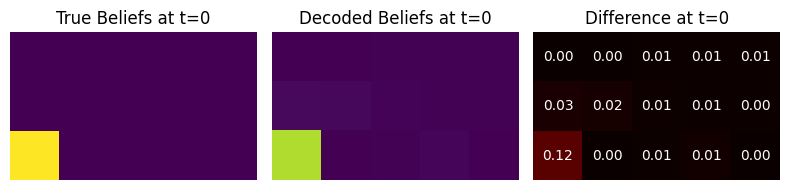

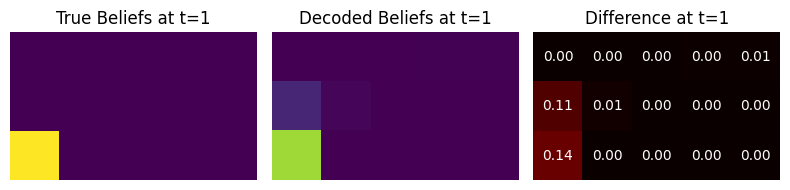

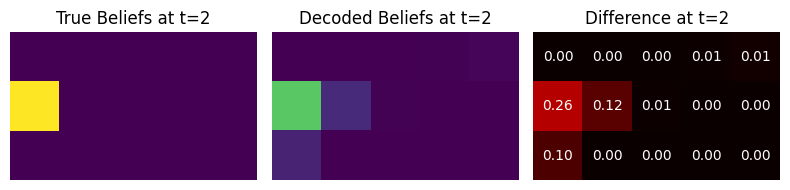

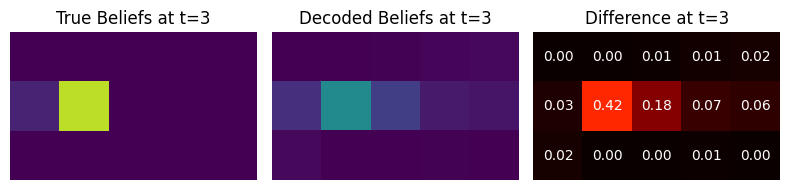

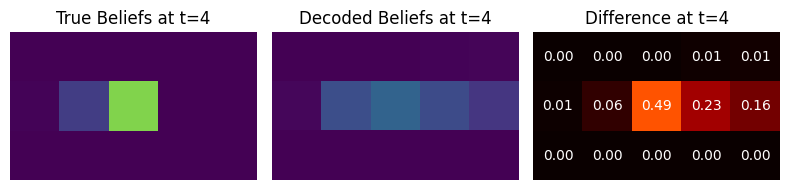

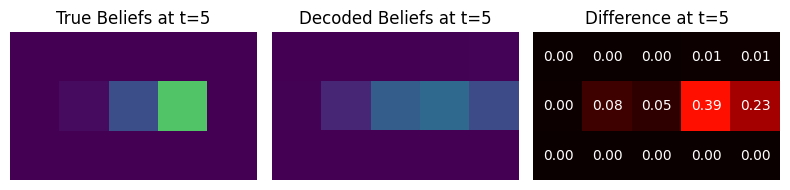

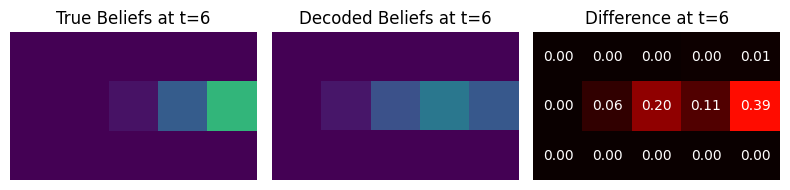

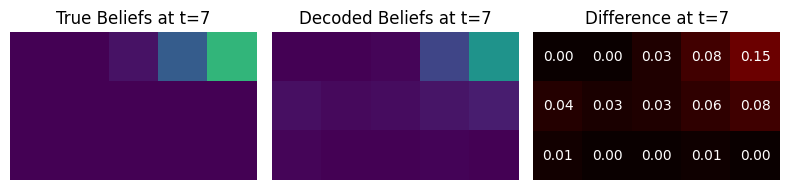

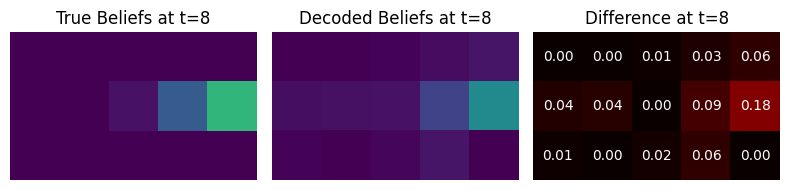

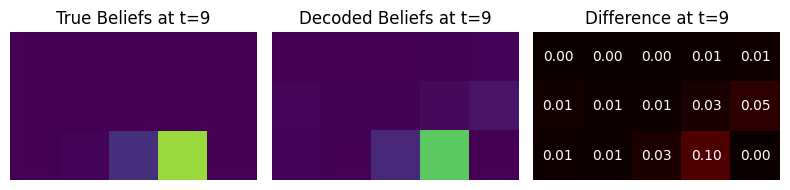

In [3]:
# Load the value RNN model from the checkpoint
model_dict = torch.load("results/res_bound_pred/0/checkpoints/checkpoint_epoch_1.pth", weights_only=True)
belief_model.load_state_dict(model_dict['model_state_dict'])
belief_model.to('cpu')


belief_decoder = LinBeliefDecoder(input_dim=belief_model.latent_dim, belief_dim=episodes.S)


belief_decoder, ce_loss, tv_loss = decode_training(
    episodes, belief_decoder, [0, None], 
    value_RNN=belief_model, num_epochs=5000, lr=1e-3)
    
   
decode_visualisation(test_episode, belief_decoder, [0, None], env_size = (3, 5), value_RNN=belief_model)

## Plot beliefs at end of training

CE Loss: 0.47 TV Loss: 0.05                                  
Belief Decoder:


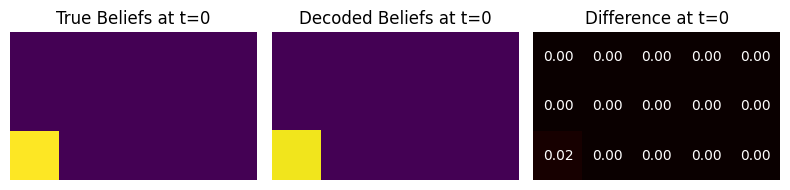

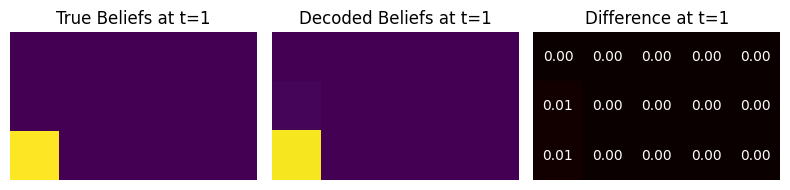

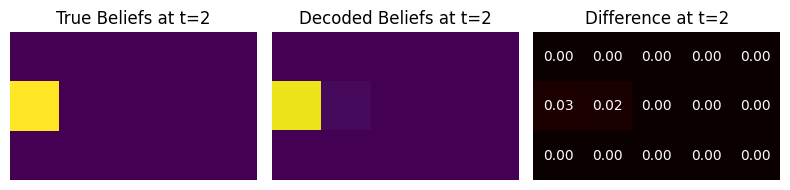

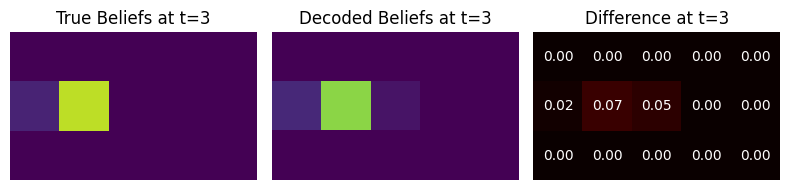

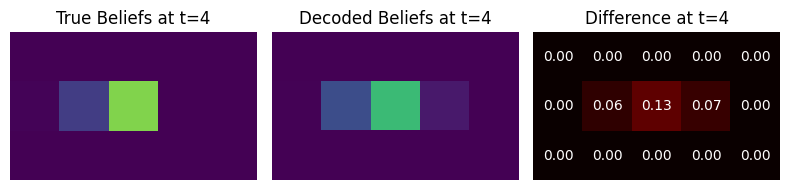

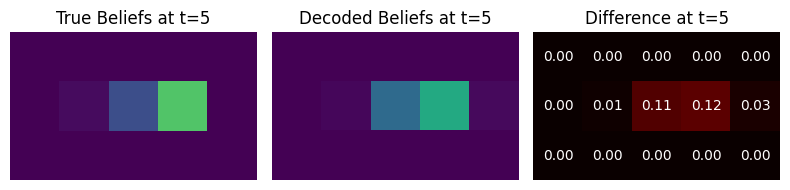

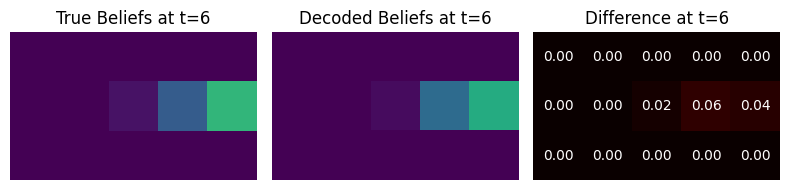

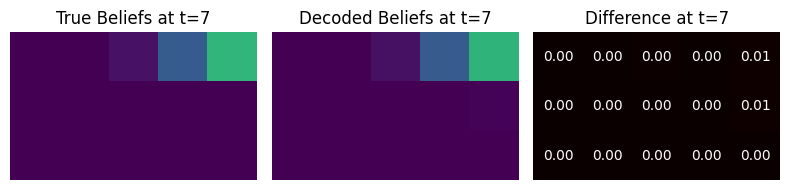

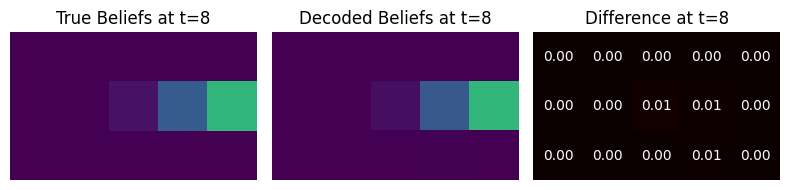

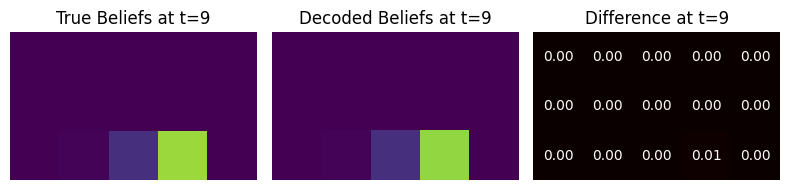

In [4]:
# Load the value RNN model from the checkpoint
model_dict = torch.load("results/res_bound_pred/0/checkpoints/checkpoint_epoch_101.pth", weights_only=True)
belief_model.load_state_dict(model_dict['model_state_dict'])
belief_model.to('cpu')


belief_decoder = LinBeliefDecoder(input_dim=belief_model.latent_dim, belief_dim=episodes.S)


belief_decoder, ce_loss, tv_loss = decode_training(
    episodes, belief_decoder, [0, None], 
    value_RNN=belief_model, num_epochs=5000, lr=1e-3)
    
   
decode_visualisation(test_episode, belief_decoder, [0, None], env_size = (3, 5), value_RNN=belief_model)